# Visualise Embedding of ResNet with SimCLR Pretraining (t-SNE)

This notebook is a mirror of `visualise_embedding.ipynb`, except that instead of using PCA to reduce the dimensionality of the embeddings, we use t-SNE.

The process involves performing PCA on the 512-dimensional embeddings to reduce the dimensionality to 50, then using t-SNE to reduce it to 2. This is a standard practice as performing t-SNE on very high-dimensional data is not recommended.

See `visualise_embedding.ipynb` for more details and comments.

In [1]:
import os

# Change this variable if the root folder name has been changed
root_dir = "nvae-shape-encoding"
current_dir = os.getcwd()

if not current_dir.endswith(root_dir):
    %cd ../..

assert os.getcwd().endswith(root_dir)

/Users/freddy/Desktop/Unshared/nvae-shape-encoding


/Users/freddy/Desktop/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import lightning as L
import torch

from arch.simclr.utils import load_simclr_backbone
from const import FRDS_MODEL_PATH, SEED
from data_modules.acdc import ACDCMaskDataModule
from utils.utils import setup_device

# Setup device
device = setup_device()
print(f"Device: {device}")

# Seed
L.seed_everything(SEED)

# Load data
data_module = ACDCMaskDataModule(batch_size=20)

# Reseed after preprocessing data
L.seed_everything(SEED)

# Load model
model = load_simclr_backbone(FRDS_MODEL_PATH)

/Users/freddy/Desktop/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 1969


Device: mps
Preprocessed training data found. Loading...
Preprocessed test data found. Loading...


Seed set to 1969


In [3]:
loader_train = data_module.train_dataloader()

# Stack each batch
data_train = []

for batch in loader_train:
    data_train.append(batch)

data_train = torch.cat(data_train, dim=0)
print(data_train.shape)

loader_test = data_module.test_dataloader()

# Stack each batch
data_test = []

for batch in loader_test:
    data_test.append(batch)

data_test = torch.cat(data_test, dim=0)
print(data_test.shape)

torch.Size([1711, 4, 128, 128])
torch.Size([1076, 4, 128, 128])


In [4]:
from utils.eval import encode_embeddings

model = model.to(device)

# Extract features for train images
train_feats = encode_embeddings(data_train, model, device)
print(train_feats.shape)

# Extract features for test images
test_feats = encode_embeddings(data_test, model, device)
print(test_feats.shape)

torch.Size([1711, 512])
torch.Size([1076, 512])


In [8]:
from arch.nvae.nvae import NVAE
from arch.vae.vae import VAE
from utils.utils import discretise

def generate_data_vae(model: VAE) -> torch.Tensor:
    num_samples = 512

    # Sample from latent space
    z = torch.randn(num_samples, model.hparams.latent_dim).to(device)

    with torch.no_grad():
        model.eval()
        model.to(device)
        
        # Generate segmentation maps from latent variables
        x_fake_logits: torch.Tensor = model.decoder(z)

    return x_fake_logits

def generate_data_nvae(model: NVAE) -> torch.Tensor:
    num_samples = 512

    # Sample from latent space
    with torch.no_grad():
        model.eval()
        model.to(device)
        
        x_fake = model.decoder.generate(num_samples, device)
        feats_fake = model.conditional_coder(x_fake)

    return feats_fake

autoencoder_model_path = "logs/nvae_acdc/dynamic-warmup/pc-4-ws-6420-b0-1500000-b1-250000-b2-25000/checkpoints/epoch=95-step=20544.ckpt"
autoencoder_model = NVAE.load_from_checkpoint(autoencoder_model_path)

good_logits = generate_data_nvae(autoencoder_model)

autoencoder_model_path = "logs/vae_acdc/info-vae/ld-8-beta-0-gamma-5/checkpoints/epoch=47-step=5136.ckpt"
autoencoder_model = VAE.load_from_checkpoint(autoencoder_model_path)

bad_logits = generate_data_vae(autoencoder_model)

good_fake_data = discretise(good_logits)
bad_fake_data = discretise(bad_logits)

good_feats = encode_embeddings(good_fake_data, model, device)
bad_feats = encode_embeddings(bad_fake_data, model, device)

print(good_feats.shape)
print(bad_feats.shape)

torch.Size([512, 512])
torch.Size([512, 512])


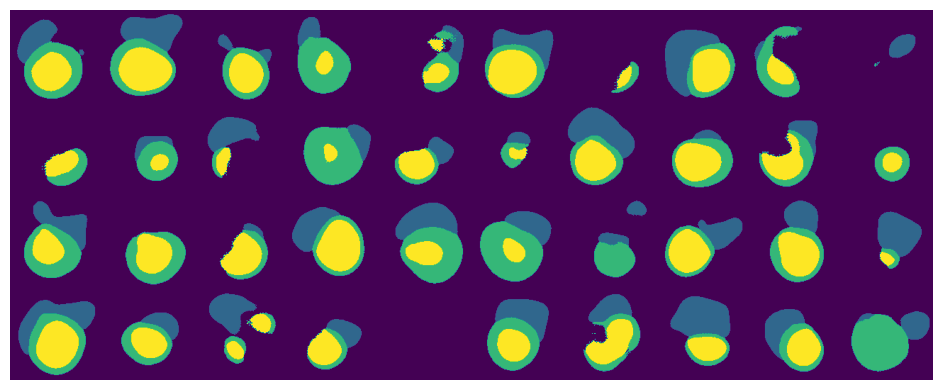

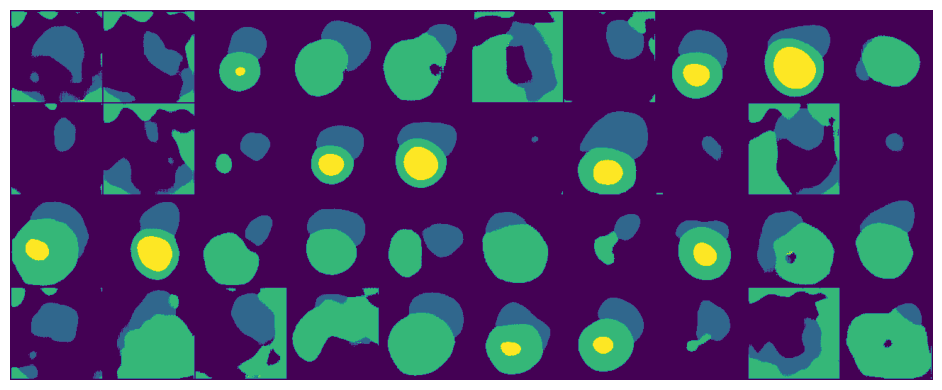

In [9]:
from utils.utils import show_samples

# View generations
good_generations = torch.argmax(good_logits, dim=1).unsqueeze(1)
show_samples(good_generations[:40], rgb=False, ncol=10, figsize=(10, 4))

bad_generations = torch.argmax(bad_logits, dim=1).unsqueeze(1)
show_samples(bad_generations[:40], rgb=False, ncol=10, figsize=(10, 4))

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=50)
pca.fit(train_feats)

train_feats_pca = pca.transform(train_feats)
test_feats_pca = pca.transform(test_feats)
good_feats_pca = pca.transform(good_feats)
bad_feats_pca = pca.transform(bad_feats)

print(train_feats_pca.shape)
print(test_feats_pca.shape)
print(good_feats_pca.shape)
print(bad_feats_pca.shape)

(1711, 50)
(1076, 50)
(512, 50)
(512, 50)


In [23]:
import numpy as np

# Concatenate the 4 arrays
feats_pca = np.concatenate([train_feats_pca, test_feats_pca, good_feats_pca, bad_feats_pca], axis=0)

# Create the corresponding labels
train_labels = np.zeros_like(train_feats_pca[:, 0])
test_labels = np.ones_like(test_feats_pca[:, 0])
good_labels = 2 * np.ones_like(good_feats_pca[:, 0])
bad_labels = 3 * np.ones_like(bad_feats_pca[:, 0])

labels = np.concatenate([train_labels, test_labels, good_labels, bad_labels], axis=0).astype(int)

In [26]:
tsne = TSNE(
    n_components=2,
    learning_rate="auto",
    init="random",
    perplexity=30,
)

feats_reduced = tsne.fit_transform(feats_pca)
print(feats_reduced.shape)

(3811, 2)


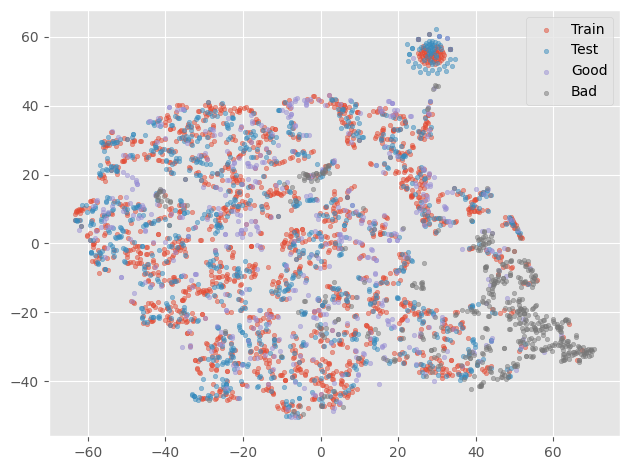

In [32]:
from matplotlib import pyplot as plt

plt.style.use("ggplot")

for i in range(4):
    plt.scatter(
        feats_reduced[labels == i, 0],
        feats_reduced[labels == i, 1],
        alpha=0.5,
        s=10,
    )

plt.tight_layout()
plt.legend(["Train", "Test", "Good", "Bad"])
plt.show()